In [1]:
import numpy as np
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import os
import lr1b



## Implementation of the channel spectral sensitivity correction as reported in AN000633

Measured 3 AMBITs along with a spectrometer (LR1-B). The dataset is used to estimate the AS7341 channel sensitivity and then to do a linear regression to predict PAR.
- §2.1 Calculate basic counts
- §2.2 remove default offset
- Calculate the "real irradiance" of the LR1-B corrected by its exposure (ms) and calibration sensitivity response
- §2.4 calculate the AS7341 channel sensitivity

Differences from the miniPAR dataset: the AMBIT rows come from binary cmd 35 (`get_spec_raw`) — ten **unscaled** counts stored alongside the acquisition parameters they were taken under. The acquisition is fixed in firmware (gain 2×, ATIME 99, ASTEP 499) rather than randomised per capture, and the `par` column is the AMBIT's own onboard PAR (there is no Licor `tia_par` in this rig).

NB §2.3 not reported  since it is a situational fallback for unstable NIR without a matrix; the reconstruction matrix's negative lobes (e.g. F2 = −0.0339 and Clear = −0.0070 at 380 nm) already subtract the out-of-band leakage. Applying both would double-correct.

In [2]:
XLSX = '../Firmware/docs/AS7341_AD000198_3-00.xlsx'
DATA = "data/"
CH = ['f1_415', 'f2_445', 'f3_480', 'f4_515', 'f5_555',
      'f6_590', 'f7_630', 'f8_680', 'clear', 'nir']

df = pd.read_csv(os.path.join(DATA, 'multi_ambit_spec_lr1b.csv'))
grid = np.loadtxt(os.path.join(DATA, 'lr1b_spectra_ambit', os.path.basename(p=df.lr1b_spectrum_file.iloc[0])))[:, 0]

print('rows %d | captures %d | devices %d | tags %d | PAR %.1f-%.1f'
      % (len(df), df.measurement.nunique(), df.ambit.nunique(),
         df.metadata.nunique(), df.par.min(), df.par.max()))

rows 162 | captures 54 | devices 3 | tags 1 | PAR 3.6-132.9


In [3]:

# The .clbr is device-specific: assert it reproduces the data's own wavelength grid.
cal = lr1b.Calibration.from_file(os.path.join(DATA, 'N 3163.clbr'))
order = np.argsort(cal.wavelengths)          # device order is descending; files are ascending
assert len(cal.wavelengths) == len(grid), 'clbr has %d pixels, data has %d' % (len(cal.wavelengths), len(grid))
gap = float(np.max(np.abs(cal.wavelengths[order] - grid)))
assert gap < 1e-6, 'N 3163.clbr does not reproduce the data wavelength grid (%.4f nm)' % gap

irr_a, prnu_a = cal.irr_norm[order], cal.prnu_norm[order]
ok = irr_a > 0
print('cal serial %s | grid match %.1e nm | irradiance pixels %d/%d (%.1f-%.1f nm)'
      % (cal.serial, gap, ok.sum(), ok.size, grid[ok].min(), grid[ok].max()))


cal serial 3163 | grid match 0.0e+00 nm | irradiance pixels 3648/3648 (296.9-1017.5 nm)


## The published correction values

From sheet `used Correction Values`: the Golden-Device spectral reconstruction matrix (1 nm,
380–1100 nm, one column per channel) and the example offset vector.

In [4]:
ws = openpyxl.load_workbook(XLSX, data_only=True)['used Correction Values']
rows = []
for r in range(6, ws.max_row + 1):
    v = [ws.cell(r, c).value for c in range(1, 12)]          # A = WV, B..K = F1..NIR
    if all(isinstance(x, (int, float)) for x in v):
        rows.append(v)
cm = np.array(rows, float)
cm_wv, CM = cm[:, 0], cm[:, 1:]                              # (721,), (721, 10)
assert CM.shape[1] == len(CH)
print('CM %s, %g-%g nm, step %g nm' % (CM.shape, cm_wv.min(), cm_wv.max(), cm_wv[1] - cm_wv[0]))

# Workbook 'Offset, measured with sensor' (row 15, cols O..X) — ams units, i.e. t_int in ms.
OFFSET_BASIC = np.array([ws.cell(15, c).value for c in range(15, 25)], float)
print('offset vector (ams units):', np.array2string(OFFSET_BASIC, precision=6))
# Firmware >= 1.06 divides by t_int in ms too, so these offsets are already in the
# device's basic-count units. Up to 1.05 the firmware divided by seconds and this
# vector had to be multiplied by 1000 first.
print('  -> firmware >= 1.06 basic counts (same units):',
      np.array2string(OFFSET_BASIC, precision=6))

CM (721, 10), 380-1100 nm, step 1 nm
offset vector (ams units): [0.00197  0.007249 0.003194 0.001315 0.001468 0.001858 0.001763 0.005217
 0.003    0.001   ]
  -> firmware >= 1.06 basic counts (same units): [0.00197  0.007249 0.003194 0.001315 0.001468 0.001858 0.001763 0.005217
 0.003    0.001   ]


## Calculate basic counts §2.1 , then remove offset as in §2.2
Use the default channel offset reported by ams.

The AMBIT CSV stores the AS7341 gain three ways: the two SMUX bank registers (`gain_low`, `gain_high`, fixed equal in firmware) and the ready-made multiplier `gain_x`.

`gainRegToMultiplier()` maps `0 → 0.5×`, else `1 << (reg-1)`.

In [5]:

def gain_multiplier(reg):
    return 0.5 if reg == 0 else float(1 << (int(reg) - 1))

# cmd 35 counts are UNSCALED, so one gain x t_int factor per row normalises every
# channel - valid only while both SMUX bank gains stay equal, as the firmware fixes them.
assert (df.gain_low == df.gain_high).all(), 'bank gains differ - normalise per channel bank'
assert np.allclose(df.gain_x, df.gain_low.map(gain_multiplier)), 'gain_x does not match the gain_low register'

# t_int in MILLISECONDS -> the ams basic-count convention the workbook's values assume.
gt_ms = df.gain_x * (df.atime + 1) * (df.astep + 1) * 2.78e-3
basic = df[CH].to_numpy(float) / gt_ms.to_numpy()[:, None]           # §2.1
sensor = np.clip(basic - OFFSET_BASIC, 0.0, None)                    # §2.2

print('gain registers present: %s -> multipliers %s'
      % (sorted(df.gain_low.unique()), [gain_multiplier(g) for g in sorted(df.gain_low.unique())]))
print('basic counts (ams units): median %.4g, range %.3g .. %.3g'
      % (np.median(basic), basic.min(), basic.max()))
print('offset is %.2f%% .. %.2f%% of the median signal; rows clipped to zero: %d'
      % (100 * OFFSET_BASIC.min() / np.median(basic),
         100 * OFFSET_BASIC.max() / np.median(basic),
         int((basic - OFFSET_BASIC < 0).any(axis=1).sum())))
print('workbook example basic counts for scale: F1 0.0441, Clear 0.6613')

gain registers present: [np.int64(2)] -> multipliers [2.0]
basic counts (ams units): median 0.1043, range 0 .. 1.27
offset is 0.96% .. 6.95% of the median signal; rows clipped to zero: 5
workbook example basic counts for scale: F1 0.0441, Clear 0.6613


## Calibrated LR1-B irradiance, and the reference channel values

`lr1b.Spectrum.irradiance()`:
`E = counts × irr_norm / (prnu_norm × irr_scaler × exposure_in_10µs)`.

The workbook's §2.4 correction vector is `reference / sensor` per channel. The reference is
*what each channel should read* for the measured spectrum — obtained here by inverting the
published CM in the least-squares sense, so the reference is by construction the channel vector
that reconstructs to the observed spectrum. The inversion is restricted to the wavelengths where
both the CM and the LR1-B are valid (**380–1017 nm**); the CM's 1018–1100 nm rows have no
reference data behind them.

In [6]:
overlap = (cm_wv >= max(380.0, grid[ok].min())) & (cm_wv <= min(1100.0, grid[ok].max()))
print('CM rows with LR1-B support: %d/%d (%g-%g nm)'
      % (overlap.sum(), overlap.size, cm_wv[overlap].min(), cm_wv[overlap].max()))

_cache = {}
def irradiance_on_cm_grid(fname, exposure_ms):
    # account for the change in exposure
    # based on the  calibration file
    key = (fname, float(exposure_ms))
    if key not in _cache:
        counts = np.loadtxt(os.path.join(DATA , 'lr1b_spectra_ambit' , fname))[:, 1]
        E = np.zeros_like(counts)
        ticks = exposure_ms / lr1b.EXPOSURE_TICK_MS
        E[ok] = counts[ok] * irr_a[ok] / (prnu_a[ok] * cal.irr_scaler * ticks) # account photo-response non-uniformity, irr_a, irr_scaler er-pixel factor that turns counts/time into physical irradiance, from calibration file
        _cache[key] = np.interp(cm_wv, grid, E) # resamples the measured spectrum to match ams file
    return _cache[key]

files = [os.path.basename(p) for p in df.lr1b_spectrum_file]
E_all = np.array([irradiance_on_cm_grid(f, e)
                  for f, e in zip(files, df.lr1b_exposure_ms)])          # (n, 721)

reference = np.linalg.lstsq(CM[overlap, :], E_all[:, overlap].T, rcond=None)[0].T   # (n, 10)
print('irradiance over the overlap: median %.4g, max %.4g' % (np.median(E_all[:, overlap]), E_all.max()))
print('reference channel values:    median %.4g' % np.median(reference))

CM rows with LR1-B support: 638/721 (380-1017 nm)
irradiance over the overlap: median 0.0162, max 0.3766
reference channel values:    median 1.896


## §2.4 Correction vector — `reference / sensor`, per channel, per device
For each measurement, the ratio `reference (LR1-B) / sensor (AS7341)` is computed. 

With `sensor` = `Basic_Counts (§2.1) - Offset ( §2.2)`

The median for each device is then reported in the table 



In [7]:
devices = sorted(df.ambit.unique())
ratio = reference / np.maximum(sensor, 1e-12)
factor = {d: np.median(ratio[(df.ambit == d).to_numpy()], axis=0) for d in devices}

tbl = pd.DataFrame(factor, index=CH).T
tbl.loc['spread %'] = (tbl.max() - tbl.min()) / tbl.mean() * 100
display(tbl.round(3))

SPECTRAL_COEF = tbl.iloc[:-1,:].mean(axis=0)

F = np.array([factor[d] for d in df.ambit])
corrected = F * sensor                                   # workbook F10 = E10*(C10-D10)
reconstructed = corrected @ CM.T                         # (n, 721)
print('reconstructed spectra:', reconstructed.shape)
print("\nAveraged spectral coeficient:")
print(SPECTRAL_COEF)

,f1_415,f2_445,f3_480,f4_515,f5_555,f6_590,f7_630,f8_680,clear,nir
ambit_AmbitV003_3CDC750BEAA4,18.513,36.182,32.693,22.645,18.301,15.680,14.993,15.027,16.701,8.116
ambit_AmbitV003_3CDC750BF0F4,18.656,35.142,32.587,22.537,18.199,15.827,15.142,15.709,16.337,8.655
ambit_AmbitV003_3CDC750BF1A4,12.595,25.950,24.461,17.063,13.616,12.105,11.694,11.960,12.434,6.956
spread %,36.537,31.555,27.518,26.903,28.041,25.599,24.727,26.344,28.148,21.480


reconstructed spectra: (162, 721)

Averaged spectral coeficient:
f1_415    16.588213
f2_445    32.424491
f3_480    29.913822
f4_515    20.748268
f5_555    16.705340
f6_590    14.537499
f7_630    13.942882
f8_680    14.232045
clear     15.157123
nir        7.909340
dtype: float64


### Reconstruction vs LR1-B — overlay

`corrected @ CM.T` puts the AS7341 back on the 1 nm grid in the same irradiance units as the LR1-B, so the two can be overlaid directly. Shown for the lowest-, median- and highest-PAR rows, restricted to the 380–1017 nm overlap the correction was fitted on. The reconstruction is built from ten channels, so it can only follow the broad shape — the RMS in each title is relative to the mean measured irradiance over the band.

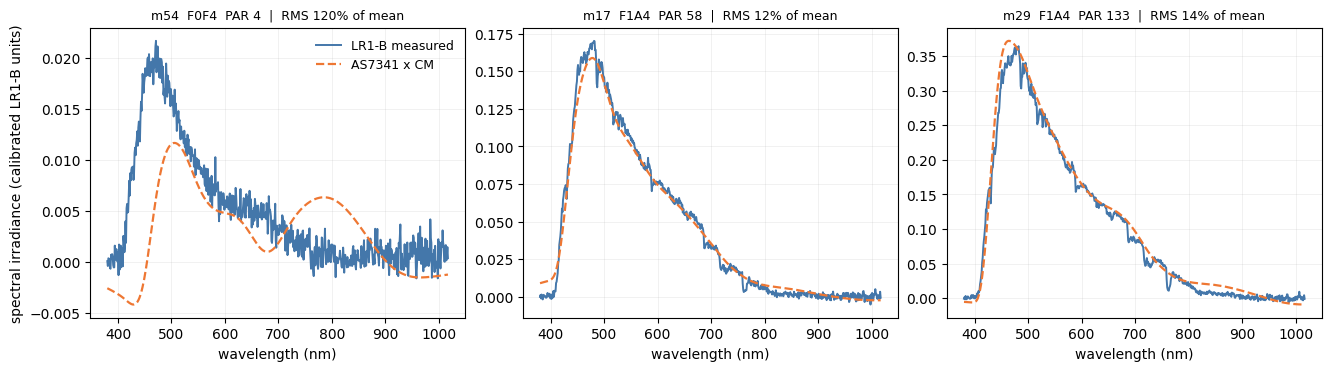

In [8]:
MEASURED, RECON = '#4477aa', '#ee7733'      # colorblind-safe blue/orange (Tol bright)

by_par = df.par.sort_values().index
pick = list(dict.fromkeys([by_par[0], by_par[len(by_par) // 2], by_par[-1]]))

wv = cm_wv[overlap]
fig, axes = plt.subplots(1, len(pick), figsize=(4.4 * len(pick), 3.6),
                         constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, i in zip(axes, pick):
    meas, rec = E_all[i, overlap], reconstructed[i, overlap]
    rms = np.sqrt(np.mean((rec - meas) ** 2)) / np.mean(meas) * 100
    ax.plot(wv, meas, color=MEASURED, lw=1.4, label='LR1-B measured')
    ax.plot(wv, rec, color=RECON, lw=1.6, ls='--', label='AS7341 x CM')
    dev = df.ambit.iloc[i].split('_')[-1][-4:]        # last 4 of the MAC
    ax.set_title('m%02d  %s  PAR %.0f  |  RMS %.0f%% of mean'
                 % (df.measurement.iloc[i], dev, df.par.iloc[i], rms), fontsize=9)
    ax.set_xlabel('wavelength (nm)')
    ax.grid(alpha=0.25, lw=0.5)
axes[0].set_ylabel('spectral irradiance (calibrated LR1-B units)')
axes[0].legend(frameon=False, fontsize=9)
plt.show()

### Apply §2.1, §2.2 and the `Averaged spectral coeficient` for each measurements, then predict par.




In [9]:
# The deployable chain: raw channel counts -> irradiance-like signal, with ONE
# device-independent coefficient vector (no per-device `factor` lookup).
def to_signal(frame):
    """§2.1 basic counts -> §2.2 default offset -> §2.4 averaged spectral coefficient."""
    gt = frame.gain_x * (frame.atime + 1) * (frame.astep + 1) * 2.78e-3   # ms
    b = frame[CH].to_numpy(float) / gt.to_numpy()[:, None]        # §2.1 basic counts
    s = np.clip(b - OFFSET_BASIC, 0.0, None)                      # §2.2 offset removed
    return s * SPECTRAL_COEF.to_numpy()                           # §2.4 averaged coefficient

signal = to_signal(df)                                            # (n, 10)
X = pd.DataFrame(signal, columns=CH, index=df.index)

In [10]:
SPECTRAL_COEF

f1_415    16.588213
f2_445    32.424491
f3_480    29.913822
f4_515    20.748268
f5_555    16.705340
f6_590    14.537499
f7_630    13.942882
f8_680    14.232045
clear     15.157123
nir        7.909340
dtype: float64

In [ ]:
# The deployable chain: raw channel counts -> irradiance-like signal, with ONE
# device-independent coefficient vector (no per-device `factor` lookup).
def to_signal(frame):
    """§2.1 basic counts -> §2.2 default offset -> §2.4 averaged spectral coefficient."""
    gt = frame.gain_x * (frame.atime + 1) * (frame.astep + 1) * 2.78e-3   # ms
    b = frame[CH].to_numpy(float) / gt.to_numpy()[:, None]        # §2.1 basic counts
    s = np.clip(b - OFFSET_BASIC, 0.0, None)                      # §2.2 offset removed
    return s * SPECTRAL_COEF.to_numpy()                           # §2.4 averaged coefficient

signal = to_signal(df)                                            # (n, 10)
X = pd.DataFrame(signal, columns=CH, index=df.index)